In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Standard library
import gc
import importlib
import os
import sys
from pathlib import Path

# Data / numerical work
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt

# Machine learning utilities
from sklearn.model_selection import train_test_split

# Deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Metrics / optimization / progress
import torchmetrics
import optuna
from tqdm.auto import tqdm

# Your package: data preparation
from autoseqmodels.data_prep import loader, inspection, encoders, sequence_builder

from autoseqmodels.data_prep.inspection import (
    infer_column_types,
    propose_structure,
    classify_time_variance,
    plan_covariates,
    CovariatePlan,
)

# Your package: models / training
from autoseqmodels.models import (
    training,
    sequence_lstm,
    sequence_transformer,
)

In [3]:
import numpy as np, pandas as pd
from autoseqmodels.data_prep.loader import _coerce_merge_key

# --- Dates (change these to re-define the train / holdout windows;
#     every downstream cell derives its T_CAL / T_HOLD from here).
training_start, training_end = pd.Timestamp("1999-01-01"), pd.Timestamp("2000-12-31")
holdout_start,  holdout_end  = pd.Timestamp("2001-01-01"), pd.Timestamp("2002-12-31")

WEEKS_PER_YEAR = 52
T_CAL  = (training_end.year - training_start.year + 1) * WEEKS_PER_YEAR
T_HOLD = (holdout_end.year  - holdout_start.year  + 1) * WEEKS_PER_YEAR

# --- Load + clean
tx_df, cov_df = loader.load_table(
    path="Datasets/Electronics_Retailer_data.Rdata",
    r_base_object_name="mydata", r_covariates_object_name="covariates.dynamic")
tx_df["Id"], cov_df["Id"] = _coerce_merge_key(tx_df["Id"], cov_df["Id"])
tx_df["Date"]      = pd.to_datetime(tx_df["Date"])
cov_df["Cov.Date"] = pd.to_datetime(cov_df["Cov.Date"])

# --- Cohort: first purchase <= training_end
cohort = tx_df.groupby("Id")["Date"].min()
cohort = cohort[cohort <= training_end].index

# --- Weekly transaction counts on a full (Id x year x week) grid
def add_yw(df, col):
    df["year"] = df[col].dt.year
    df["week"] = (df[col].dt.dayofyear // 7).clip(upper=WEEKS_PER_YEAR - 1)
add_yw(tx_df, "Date")
weekly = (tx_df[tx_df["Id"].isin(cohort)]
          .groupby(["Id","year","week"]).size().reset_index(name="Transactions"))
years, weeks = range(training_start.year, holdout_end.year+1), range(WEEKS_PER_YEAR)
panel = pd.MultiIndex.from_product([cohort, years, weeks],
                                    names=["Id","year","week"]).to_frame(index=False)
panel = panel.merge(weekly, on=["Id","year","week"], how="left").fillna({"Transactions": 0})

# Merging
# --- Merge covariates (Gender/Income static, high.season time-varying)
add_yw(cov_df, "Cov.Date")
cov_w = (cov_df[cov_df["Id"].isin(cohort)]
         .groupby(["Id","year","week"], as_index=False)
         .agg({"Gender":"first", "Income":"first", "high.season":"max"}))
panel = panel.merge(cov_w, on=["Id","year","week"], how="left").sort_values(["Id","year","week"])
for c in ["Gender","Income","high.season"]:
    panel[c] = panel.groupby("Id")[c].ffill().bfill()

# --- Engineered features
panel["week_sin"] = np.sin(2*np.pi*panel["week"]/WEEKS_PER_YEAR)
panel["week_cos"] = np.cos(2*np.pi*panel["week"]/WEEKS_PER_YEAR)
panel["year_idx"] = panel["year"] - training_start.year

# --- Split + reshape into (N, T, F).  Transactions LAST so it is column -1
features = ["Gender","Income","high.season","week_sin","week_cos","year_idx","Transactions"]
N = len(cohort)
def block(df, T):
    return df.sort_values(["Id","year","week"])[features].to_numpy("float32").reshape(N, T, len(features))

calibration = block(panel[panel["year"] <  holdout_start.year], T_CAL)
holdout     = block(panel[panel["year"] >= holdout_start.year], T_HOLD)
samples     = calibration[:, :-1, :]
targets     = calibration[:,  1:, -1]

print(f"T_CAL={T_CAL}  T_HOLD={T_HOLD}")
print(f"calibration {calibration.shape} | samples {samples.shape} | targets {targets.shape} | holdout {holdout.shape}")


T_CAL=104  T_HOLD=104
calibration (829, 104, 7) | samples (829, 103, 7) | targets (829, 103) | holdout (829, 104, 7)


In [4]:
# --- Integrity checks (focus: merge correctness) ---

# 1) Cohort overlap — both frames must contain every cohort Id
tx_ids  = set(tx_df["Id"].unique())
cov_ids = set(cov_df["Id"].unique())
assert not (set(cohort) - tx_ids),  "cohort Ids missing from tx_df"
assert not (set(cohort) - cov_ids), "cohort Ids missing from cov_df (Id dtype mismatch?)"
print(f"Cohort Ids                  : {len(cohort):,}  (present in both frames)")

# 2) Transaction-grid merge — row count is exactly N x years x WEEKS_PER_YEAR, no duplication
expected_rows = len(cohort) * len(list(years)) * len(list(weeks))
assert len(panel) == expected_rows, f"panel row count {len(panel)} != {expected_rows}"
weekly_in_win = weekly[weekly["year"].between(training_start.year, holdout_end.year)]
assert int(panel["Transactions"].sum()) == int(weekly_in_win["Transactions"].sum()), \
    "Transactions in panel != transactions in weekly within window"
print(f"Panel rows                  : {len(panel):,}  (= N x years x {WEEKS_PER_YEAR})")
print(f"Total tx in panel (window)  : {int(panel['Transactions'].sum()):,}")

# 3) Covariate aggregation produced unique (Id, year, week) keys
assert not cov_w.duplicated(subset=["Id","year","week"]).any(), \
    "cov_w has duplicate keys — would explode panel rows"

# 4) Covariate merge did NOT change panel row count
assert len(panel) == expected_rows, "panel rows changed after covariate merge"

# 5) Gender / Income invariant per customer (justifies 'first' agg)
nu = cov_df.groupby("Id")[["Gender","Income"]].nunique().max()
assert nu["Gender"] == 1, "Gender varies within a customer in cov_df"
assert nu["Income"] == 1, "Income varies within a customer in cov_df"
print(f"Gender / Income per customer: invariant")

# 6) high.season is binary in cov_df
hs_vals = set(cov_df["high.season"].unique())
assert hs_vals.issubset({0, 1}), f"high.season has non-binary values: {hs_vals}"

# 7) Coverage rate before fill — surfaces gaps in cov_df
tmp = panel[["Id","year","week"]].merge(cov_w, on=["Id","year","week"], how="left")
print(f"Cov match rate (raw)        : {tmp['high.season'].notna().mean():.1%}  (gaps filled by ffill/bfill)")

# 8) After ffill+bfill, no NaN remain in any covariate
for c in ["Gender","Income","high.season"]:
    assert panel[c].notna().all(), f"panel['{c}'] still has NaN after fill"
print(f"Covariates after fill       : 0 NaN")

# 9) Total transactions preserved end-to-end (raw -> panel)
raw_in_window = (tx_df["Date"].between(training_start, holdout_end)
                 & tx_df["Id"].isin(cohort))
assert int(panel["Transactions"].sum()) == int(raw_in_window.sum()), \
    "Transactions drifted between raw tx_df (in window, in cohort) and panel"

# 10) Tensor shapes — all derived from T_CAL / T_HOLD
assert calibration.shape == (N, T_CAL,     len(features))
assert holdout.shape     == (N, T_HOLD,    len(features))
assert samples.shape     == (N, T_CAL - 1, len(features))
assert targets.shape     == (N, T_CAL - 1)

# 11) Reshape conserved totals on each split
tx_train = panel[panel["year"] <  holdout_start.year]["Transactions"].sum()
tx_hold  = panel[panel["year"] >= holdout_start.year]["Transactions"].sum()
assert int(calibration[:, :, -1].sum()) == int(tx_train), "training tx mismatch after reshape"
assert int(holdout[:, :, -1].sum())     == int(tx_hold),  "holdout tx mismatch after reshape"

# 12) AR shift correctness
assert np.allclose(targets, calibration[:, 1:, -1])

# 13) Customer order identical across train and holdout slices
tr_ids = panel[panel["year"] <  holdout_start.year].sort_values(["Id","year","week"])["Id"].unique()
ho_ids = panel[panel["year"] >= holdout_start.year].sort_values(["Id","year","week"])["Id"].unique()
assert (tr_ids == ho_ids).all(), "Customer order differs between train and holdout"

# 14) Per-customer week count exactly T_CAL / T_HOLD
assert (panel[panel["year"] <  holdout_start.year].groupby("Id").size() == T_CAL).all()
assert (panel[panel["year"] >= holdout_start.year].groupby("Id").size() == T_HOLD).all()

# 15) Categorical/binary value ranges in the final tensors
for col, idx, expect in [("Gender", 0, {0.0, 1.0}), ("high.season", 2, {0.0, 1.0})]:
    vals = set(np.unique(calibration[:, :, idx]).tolist())
    assert vals.issubset(expect), f"{col} values {vals} not in {expect}"

print(f"Max tx / week (train)       : {int(calibration[:, :, -1].max())}")
print(f"Max tx / week (holdout)     : {int(holdout[:, :, -1].max())}")
print()
print(f"Tensors                     : calibration {calibration.shape} | samples {samples.shape} | targets {targets.shape} | holdout {holdout.shape}")
print("All integrity checks passed")


Cohort Ids                  : 829  (present in both frames)
Panel rows                  : 172,432  (= N x years x 52)
Total tx in panel (window)  : 7,950
Gender / Income per customer: invariant
Cov match rate (raw)        : 99.5%  (gaps filled by ffill/bfill)
Covariates after fill       : 0 NaN
Max tx / week (train)       : 22
Max tx / week (holdout)     : 26

Tensors                     : calibration (829, 104, 7) | samples (829, 103, 7) | targets (829, 103) | holdout (829, 104, 7)
All integrity checks passed


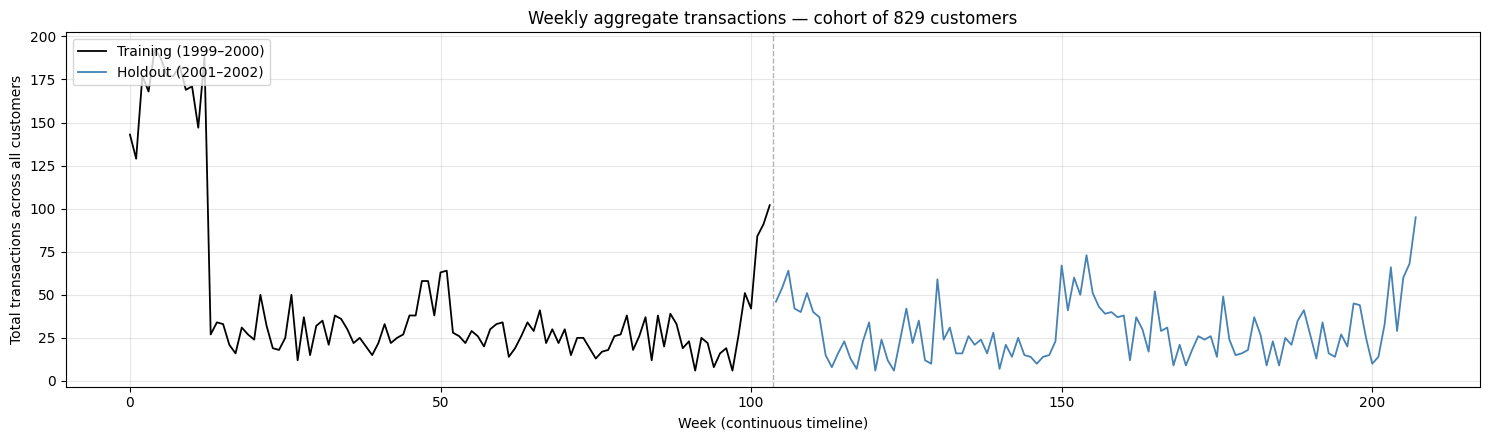

Weeks in training : 104 (T_CAL=104)
Weeks in holdout  : 104 (T_HOLD=104)
Total tx training : 4,942
Total tx holdout  : 3,008


In [5]:
# === Weekly aggregate plot — training vs holdout ===
# Sum Transactions across all customers per (year, week), then plot the full
# timeline with the training and holdout segments in different colors.

weekly_agg = (panel.groupby(["year", "week"], as_index=False)["Transactions"].sum()
                   .sort_values(["year", "week"])
                   .reset_index(drop=True))

# Boolean masks for the two segments
is_train = weekly_agg["year"] < holdout_start.year
is_hold  = weekly_agg["year"] >= holdout_start.year

# X-axis: continuous week index (0..T_CAL+T_HOLD-1)
x = np.arange(len(weekly_agg))

fig, ax = plt.subplots(figsize=(15, 4.5))
ax.plot(x[is_train], weekly_agg.loc[is_train, "Transactions"],
        color="black",     linewidth=1.3, label=f"Training ({training_start.year}–{training_end.year})")
ax.plot(x[is_hold],  weekly_agg.loc[is_hold,  "Transactions"],
        color="steelblue", linewidth=1.3, label=f"Holdout ({holdout_start.year}–{holdout_end.year})")
ax.axvline(T_CAL - 0.5, color="grey", linestyle="--", linewidth=1, alpha=0.6)
ax.set_xlabel("Week (continuous timeline)")
ax.set_ylabel("Total transactions across all customers")
ax.set_title(f"Weekly aggregate transactions — cohort of {N:,} customers")
ax.legend(loc="upper left"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Weeks in training : {is_train.sum()} (T_CAL={T_CAL})")
print(f"Weeks in holdout  : {is_hold.sum()} (T_HOLD={T_HOLD})")
print(f"Total tx training : {int(weekly_agg.loc[is_train, 'Transactions'].sum()):,}")
print(f"Total tx holdout  : {int(weekly_agg.loc[is_hold,  'Transactions'].sum()):,}")


## Hybrid GRU/LSTM + RFM/static two-output hurdle model — per-week forecast

This section trains a **count-data hurdle model** that predicts, for each customer and each
future week, the expected number of transactions. The two heads operate **per week**:

1. **Purchase head** — `P(tx in week w)` (BCE on logits, per week).
2. **Conditional count head** — `E[ log1p(tx in week w) | active that week ]` (MSE, masked).

Final per-(customer, week) prediction:

```python
y_pred[i, w] = sigmoid(p_logit[i, w]) * clamp_min0(expm1(log_amount_pred[i, w]))
```

### Adaptation to this dataset

Your data has **no monetary column**: the only target signal is the weekly transaction
count. So "amount" means **count of transactions per week**. The hurdle decomposition is
meaningful because weekly customer activity is **heavily zero-inflated**: most
customer-week cells are zero, and a single regressor compromises between the zero-mass
and the positive tail. Modelling activity and conditional intensity separately tends to
reduce bias and stabilise MAPE.

### Splits (time-based, no leakage)

| Split  | Observation window           | Target window         | Output shape per customer |
|--------|------------------------------|-----------------------|---------------------------|
| Train  | calibration weeks 0 – 51     | calibration 52 – 103  | (HORIZON,) — one per week |
| Val    | calibration weeks 0 – 51     | calibration 52 – 103  | (HORIZON,) — one per week |
| Test   | calibration weeks 52 – 103   | holdout 0 – 51        | (HORIZON,) — one per week |

Train and test observation windows are **disjoint in time**. All feature scaling uses
training statistics only. Sequence features never look beyond the observation window.

### Metrics

- **Per-customer total** (matches existing baselines): aggregate predictions over the
  HORIZON axis before computing RMSE / MAE / MAPE / bias.
- **Per-cell** (customer x week): same metrics on the flat (N x HORIZON) array — much
  more demanding because cells are mostly zero.


In [6]:
# === Hurdle model — configuration (rolling windows, per-step decoder) ===
import random
from sklearn.preprocessing import StandardScaler

SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)
set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Window sizes (rolling within calibration so each customer contributes many pairs)
OBS_LEN = 26          # 6 months observation
HORIZON = 26          # 6 months prediction
STRIDE  = 4           # roll the window forward 4 weeks at a time
assert OBS_LEN + HORIZON <= T_CAL
assert HORIZON <= T_HOLD

# --- Training hyperparameters (smaller model, lower LR, smaller batch)
BATCH_SIZE     = 64
EPOCHS         = 100
PATIENCE       = 15
LR             = 3e-4
HIDDEN         = 32
DROPOUT        = 0.2
RNN_TYPE       = "GRU"
AMOUNT_WEIGHT  = 1.0

# --- Feature column mappings (must match the order set in the data prep cell)
FEAT_NAMES   = ["Gender", "Income", "high.season", "week_sin", "week_cos", "year_idx", "Transactions"]
IDX          = {n: i for i, n in enumerate(FEAT_NAMES)}

# Sequence features fed to the encoder (year_idx dropped — would identify the calendar year)
SEQ_COLS     = ["Transactions", "high.season", "week_sin", "week_cos"]
SEQ_IDX      = [IDX[c] for c in SEQ_COLS]

# Future-step time features fed to the per-step decoder head. These are calendar features
# that are KNOWN in advance (sin/cos of week-of-year + the calendar high.season flag) —
# legal to use as inputs at prediction time.
TIME_COLS    = ["week_sin", "week_cos", "high.season"]
TIME_IDX     = [IDX[c] for c in TIME_COLS]

STATIC_NAMES = ["Gender", "Income", "recency", "frequency", "total_tx",
                "avg_per_week", "avg_per_active_week", "std_per_week"]

print(f"Device       : {DEVICE}")
print(f"OBS_LEN      : {OBS_LEN}   HORIZON: {HORIZON}   STRIDE: {STRIDE}")
print(f"Seq feats    : {SEQ_COLS}")
print(f"Time feats   : {TIME_COLS}")
print(f"Static feats : {STATIC_NAMES}")
print(f"Model        : hidden={HIDDEN}  lr={LR}  batch={BATCH_SIZE}")


Device       : cuda
OBS_LEN      : 26   HORIZON: 26   STRIDE: 4
Seq feats    : ['Transactions', 'high.season', 'week_sin', 'week_cos']
Time feats   : ['week_sin', 'week_cos', 'high.season']
Static feats : ['Gender', 'Income', 'recency', 'frequency', 'total_tx', 'avg_per_week', 'avg_per_active_week', 'std_per_week']
Model        : hidden=32  lr=0.0003  batch=64


In [7]:
# === Feature engineering: rolling windows + time-aware features ===
# Strategy:
#   - For training/val: roll a (OBS_LEN, HORIZON) window across calibration in steps of STRIDE.
#     Each customer contributes ~((T_CAL - OBS_LEN - HORIZON) / STRIDE + 1) pairs.
#   - For test: ONE pair per customer using the last OBS_LEN weeks of calibration as obs and
#     the first HORIZON weeks of holdout as the target.
#   - Customer-level train/val split is done BEFORE rolling expansion so that windows from a
#     given customer never appear in both sets.

def build_pair(obs_block, target_block):
    """obs_block: (N, OBS_LEN, F)  target_block: (N, HORIZON, F)
    Returns (x_seq, x_static, time_feats, y_amount)."""
    # --- Sequence features (encoder input)
    x_seq = obs_block[:, :, SEQ_IDX].astype("float32")

    # --- Future-step time features (decoder input) — known in advance, no leakage
    time_feats = target_block[:, :, TIME_IDX].astype("float32")

    # --- Static / RFM features computed over the obs window
    tx_obs   = obs_block[:, :, IDX["Transactions"]]
    active   = (tx_obs > 0).astype("float32")
    freq     = active.sum(axis=1)
    total    = tx_obs.sum(axis=1)
    mean_w   = total / OBS_LEN
    mean_aw  = total / np.maximum(freq, 1.0)
    std_w    = tx_obs.std(axis=1)
    has_active  = active.any(axis=1)
    last_active = OBS_LEN - 1 - np.argmax(active[:, ::-1], axis=1)
    recency = np.where(has_active, OBS_LEN - 1 - last_active, OBS_LEN).astype("float32")
    gender = obs_block[:, 0, IDX["Gender"]]
    income = obs_block[:, 0, IDX["Income"]]
    x_static = np.column_stack([gender, income, recency, freq, total, mean_w, mean_aw, std_w]).astype("float32")

    y_amount = target_block[:, :, IDX["Transactions"]].astype("float32")
    return x_seq, x_static, time_feats, y_amount

def build_rolling(block, obs_len, horizon, stride):
    """Apply build_pair on every (start, start+obs_len, start+obs_len+horizon) window.
    Concatenate results across all starts along axis 0."""
    pieces = []
    T = block.shape[1]
    max_start = T - obs_len - horizon
    for s in range(0, max_start + 1, stride):
        obs = block[:, s:s + obs_len, :]
        tgt = block[:, s + obs_len:s + obs_len + horizon, :]
        pieces.append(build_pair(obs, tgt))
    # stack each return slot
    x_seq    = np.concatenate([p[0] for p in pieces], axis=0)
    x_static = np.concatenate([p[1] for p in pieces], axis=0)
    time_feats = np.concatenate([p[2] for p in pieces], axis=0)
    y_amount = np.concatenate([p[3] for p in pieces], axis=0)
    return x_seq, x_static, time_feats, y_amount, len(pieces)

# --- Customer-level split FIRST (no time leakage either way; customers in val are unseen)
set_seed()
perm  = np.random.permutation(N)
n_val = int(0.2 * N)
val_cust = perm[:n_val]
tr_cust  = perm[n_val:]

# --- Rolling pairs for train and val customers, within calibration only
x_seq_train, x_static_train, time_feats_train, y_amt_train, n_strides = \
    build_rolling(calibration[tr_cust],  OBS_LEN, HORIZON, STRIDE)
x_seq_val, x_static_val, time_feats_val, y_amt_val, _ = \
    build_rolling(calibration[val_cust], OBS_LEN, HORIZON, STRIDE)

# --- Test pair: last OBS_LEN weeks of cal -> first HORIZON weeks of holdout (one per customer)
x_seq_test, x_static_test, time_feats_test, y_amt_test = build_pair(
    calibration[:, T_CAL - OBS_LEN : T_CAL, :],
    holdout    [:, :HORIZON, :],
)

# --- Derived per-week targets (same shape as y_amount: (N, HORIZON))
def derive_targets(y):
    y_pur = (y > 0).astype("float32")
    y_log = np.log1p(y).astype("float32")
    return y_pur, y_log

y_pur_train, y_log_train = derive_targets(y_amt_train)
y_pur_val,   y_log_val   = derive_targets(y_amt_val)
y_pur_test,  y_log_test  = derive_targets(y_amt_test)

print(f"Rolling strides per customer : {n_strides}")
print(f"Train pairs : {len(y_amt_train):,}   Val pairs : {len(y_amt_val):,}   Test pairs : {len(y_amt_test):,}")
print(f"x_seq shape : {x_seq_train.shape}    x_static shape : {x_static_train.shape}")
print(f"time_feats  : {time_feats_train.shape}                y_amount shape : {y_amt_train.shape}")
print(f"P(tx | cell): train={y_pur_train.mean():.3f}   val={y_pur_val.mean():.3f}   test={y_pur_test.mean():.3f}")
print(f"Mean weekly : train={y_amt_train.mean():.3f}   val={y_amt_val.mean():.3f}   test={y_amt_test.mean():.3f}")


Rolling strides per customer : 14
Train pairs : 9,296   Val pairs : 2,310   Test pairs : 829
x_seq shape : (9296, 26, 4)    x_static shape : (9296, 8)
time_feats  : (9296, 26, 3)                y_amount shape : (9296, 26)
P(tx | cell): train=0.014   val=0.019   test=0.014
Mean weekly : train=0.032   val=0.048   test=0.033


In [8]:
# === Standardise STATIC features only (fit on train) ===
# Sequence and time features are bounded (counts 0..~20, sin/cos in [-1,1], high.season 0/1)
# so the RNN / per-step head can consume them without z-scoring. Static features have very
# different scales (recency 0..26, total_tx 0..hundreds, Gender 0/1) -> must be scaled.

static_scaler = StandardScaler().fit(x_static_train)
x_static_train_s = static_scaler.transform(x_static_train).astype("float32")
x_static_val_s   = static_scaler.transform(x_static_val).astype("float32")
x_static_test_s  = static_scaler.transform(x_static_test).astype("float32")

# Sequence features kept raw (no scaling)
x_seq_train_s = x_seq_train
x_seq_val_s   = x_seq_val
x_seq_test_s  = x_seq_test

print(f"Static (scaled) : train mean={x_static_train_s.mean():+.3f} std={x_static_train_s.std():.3f}")
print(f"                  val   mean={x_static_val_s.mean():+.3f} std={x_static_val_s.std():.3f}")
print(f"                  test  mean={x_static_test_s.mean():+.3f} std={x_static_test_s.std():.3f}")


Static (scaled) : train mean=+0.000 std=1.000
                  val   mean=+0.049 std=1.208
                  test  mean=-0.072 std=1.118


In [9]:
# === PyTorch Dataset / DataLoader (now carries time_feats per sample) ===
class HurdleDataset(Dataset):
    def __init__(self, x_seq, x_static, time_feats, y_amount, y_purchase, y_log_amount):
        self.x_seq      = torch.from_numpy(x_seq)
        self.x_static   = torch.from_numpy(x_static)
        self.time_feats = torch.from_numpy(time_feats)
        self.y_amount   = torch.from_numpy(y_amount)
        self.y_purchase = torch.from_numpy(y_purchase)
        self.y_log_amt  = torch.from_numpy(y_log_amount)

    def __len__(self):
        return self.y_amount.shape[0]

    def __getitem__(self, i):
        return {
            "x_seq":        self.x_seq[i],
            "x_static":     self.x_static[i],
            "time_feats":   self.time_feats[i],
            "y_purchase":   self.y_purchase[i],
            "y_log_amount": self.y_log_amt[i],
            "y_amount":     self.y_amount[i],
        }

train_ds = HurdleDataset(x_seq_train_s, x_static_train_s, time_feats_train,
                         y_amt_train, y_pur_train, y_log_train)
val_ds   = HurdleDataset(x_seq_val_s,   x_static_val_s,   time_feats_val,
                         y_amt_val,   y_pur_val,   y_log_val)
test_ds  = HurdleDataset(x_seq_test_s,  x_static_test_s,  time_feats_test,
                         y_amt_test,  y_pur_test,  y_log_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}   Val batches: {len(val_loader)}   Test batches: {len(test_loader)}")


Train batches: 146   Val batches: 37   Test batches: 13


In [10]:
# === HurdleModel — encoder + per-step decoder head ===
# Drastically smaller heads: instead of HORIZON separate Linear(hidden -> HORIZON) heads,
# a single shared MLP head reads (context, time_feats[t]) and emits one (logit, log_amt)
# per step. With HORIZON=26 and hidden=32 this drops ~1.7k head params -> ~70.
#
#   encoder (GRU)        : sequence  -> seq_emb     (hidden,)
#   static MLP           : x_static  -> static_emb  (hidden,)
#   context              : concat the parts        (ctx_dim,)
#   per-step decoder MLP : (ctx, time_feats[t]) -> 2 outputs per step
#
# Toggle use_seq / use_static for the sequence-only / static-only baselines.

class HurdleModel(nn.Module):
    def __init__(self, n_seq_feat, n_static_feat, n_time_feat,
                 hidden=HIDDEN, rnn_type="GRU", n_layers=1, dropout=DROPOUT,
                 use_seq=True, use_static=True):
        super().__init__()
        assert use_seq or use_static, "must use at least one branch"
        self.use_seq    = use_seq
        self.use_static = use_static
        ctx_dim = 0

        if use_seq:
            rnn_cls = nn.GRU if rnn_type.upper() == "GRU" else nn.LSTM
            self.rnn = rnn_cls(n_seq_feat, hidden, num_layers=n_layers, batch_first=True,
                               dropout=dropout if n_layers > 1 else 0.0)
            ctx_dim += hidden

        if use_static:
            self.static_mlp = nn.Sequential(
                nn.Linear(n_static_feat, hidden), nn.ReLU(), nn.Dropout(dropout),
                nn.Linear(hidden, hidden),        nn.ReLU(),
            )
            ctx_dim += hidden

        # Shared per-step decoder head: (context + time_feats[t]) -> (logit_t, log_amt_t)
        self.head = nn.Sequential(
            nn.Linear(ctx_dim + n_time_feat, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 2),
        )

    def _context(self, x_seq, x_static):
        parts = []
        if self.use_seq:
            _, h = self.rnn(x_seq)
            if isinstance(h, tuple):
                h = h[0]
            parts.append(h[-1])
        if self.use_static:
            parts.append(self.static_mlp(x_static))
        return torch.cat(parts, dim=-1) if len(parts) > 1 else parts[0]   # (B, ctx_dim)

    def forward(self, x_seq, x_static, time_feats):
        ctx = self._context(x_seq, x_static)               # (B, ctx_dim)
        H   = time_feats.shape[1]
        ctx_t = ctx.unsqueeze(1).expand(-1, H, -1)         # (B, H, ctx_dim)
        x    = torch.cat([ctx_t, time_feats], dim=-1)      # (B, H, ctx_dim + n_time)
        y    = self.head(x)                                # (B, H, 2)
        return y[..., 0], y[..., 1]                         # logits, log_amt


In [11]:
# === Loss (unweighted BCE + masked MSE), metrics (paper-style), training ===

# pos_weight disabled: setting it to n_neg/n_pos pushed the BCE optimum to sigma(logit)~=0.74
# for every cell, producing +2300% bias on a 1.4%-positive target. Unweighted BCE keeps
# the model honest; the masked-MSE head still focuses the amount learning on active cells.
_n_pos = float(y_pur_train.sum())
_n_neg = float(y_pur_train.size - _n_pos)
print(f"BCE pos_weight disabled  (n_neg/n_pos = {_n_neg:.0f}/{_n_pos:.0f} = {_n_neg/max(_n_pos,1):.1f} would over-predict)")

def hurdle_loss(p_logit, log_amt_pred, batch, amount_weight=AMOUNT_WEIGHT):
    """Unweighted BCE on the purchase head + MSE masked to active cells."""
    pur = F.binary_cross_entropy_with_logits(p_logit, batch["y_purchase"])
    sq  = (log_amt_pred - batch["y_log_amount"]).pow(2)
    denom = batch["y_purchase"].sum().clamp(min=1.0)
    amt = (sq * batch["y_purchase"]).sum() / denom
    return pur + amount_weight * amt, pur.detach(), amt.detach()

def paper_metrics(pred_np, true_np):
    """5-metric protocol, matching Data_integration.ipynb. Now safely handles weeks where
    agg_true = 0 (the MAPE_agg average is taken over weeks with agg_true > 0)."""
    agg_pred = pred_np.sum(axis=0)
    agg_true = true_np.sum(axis=0)
    rmse        = float(np.sqrt(np.mean((agg_pred - agg_true) ** 2)))
    mask        = agg_true > 0
    mape        = float(np.mean(np.abs((agg_true[mask] - agg_pred[mask]) / agg_true[mask])) * 100) \
                  if mask.any() else float("nan")
    mape_paper  = float(np.sum(np.abs(agg_true - agg_pred)) / max(np.sum(agg_true), 1e-9) * 100)
    rmse_indiv  = float(np.sqrt(np.mean((pred_np - true_np) ** 2)))
    bias_pct    = float(100 * (pred_np.sum() - true_np.sum()) / max(true_np.sum(), 1e-9))
    return {"RMSE_agg": rmse, "MAPE_agg": mape, "MAPE_paper": mape_paper,
            "RMSE_indiv": rmse_indiv, "bias_%": bias_pct}

def print_paper_metrics(m, label=""):
    if label:
        print(f"--- {label} ---")
    print(f"  prediction bias        : {m['bias_%']:+.2f} %")
    print(f"  RMSE   (aggregate)     : {m['RMSE_agg']:.2f}")
    print(f"  MAPE   (aggregate)     : {m['MAPE_agg']:.2f} %")
    print(f"  MAPE   (paper method)  : {m['MAPE_paper']:.2f} %")
    print(f"  RMSE   (individual)    : {m['RMSE_indiv']:.4f}")

def predict_loader(model, loader):
    """Returns (y_pred, y_true) each of shape (N, HORIZON), original count scale."""
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for b in loader:
            b = {k: v.to(DEVICE) for k, v in b.items()}
            p_logit, log_amt = model(b["x_seq"], b["x_static"], b["time_feats"])
            p   = torch.sigmoid(p_logit)
            amt = torch.expm1(log_amt).clamp(min=0.0)
            y_pred = (p * amt).cpu().numpy()
            preds.append(y_pred)
            trues.append(b["y_amount"].cpu().numpy())
    return np.concatenate(preds, axis=0), np.concatenate(trues, axis=0)

def train_model(model, train_loader, val_loader,
                epochs=EPOCHS, lr=LR, patience=PATIENCE,
                amount_weight=AMOUNT_WEIGHT, verbose=True, log_every=5):
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    best_rmse, best_state, no_improve = float("inf"), None, 0
    for ep in range(epochs):
        model.train()
        agg = {"loss": 0.0, "pur": 0.0, "amt": 0.0, "n": 0}
        for b in train_loader:
            b = {k: v.to(DEVICE) for k, v in b.items()}
            p_logit, log_amt = model(b["x_seq"], b["x_static"], b["time_feats"])
            loss, pur, amt = hurdle_loss(p_logit, log_amt, b, amount_weight)
            opt.zero_grad(); loss.backward(); opt.step()
            bs = b["y_amount"].shape[0]
            agg["loss"] += loss.item() * bs;  agg["pur"] += pur.item() * bs
            agg["amt"]  += amt.item() * bs;   agg["n"]   += bs

        y_v, y_v_true = predict_loader(model, val_loader)
        m = paper_metrics(y_v, y_v_true)
        if verbose and (ep % log_every == 0 or ep < 3):
            mape_str = f"{m['MAPE_agg']:.1f}%" if np.isfinite(m['MAPE_agg']) else "n/a"
            print(f"  ep {ep:3d}  loss={agg['loss']/agg['n']:.3f}  "
                  f"pur={agg['pur']/agg['n']:.3f}  amt={agg['amt']/agg['n']:.3f}  "
                  f"| val RMSE_agg={m['RMSE_agg']:.2f}  MAPE_agg={mape_str}  bias={m['bias_%']:+.1f}%")
        if m["RMSE_agg"] < best_rmse - 1e-4:
            best_rmse, no_improve = m["RMSE_agg"], 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= patience:
                if verbose: print(f"  Early stop at ep {ep} (best val RMSE_agg {best_rmse:.2f})")
                break
    model.load_state_dict(best_state)
    return model


BCE pos_weight disabled  (n_neg/n_pos = 238418/3278 = 72.7 would over-predict)


In [12]:
# === Train all variants — paper-style metrics ===
n_seq_feat    = x_seq_train_s.shape[-1]
n_static_feat = x_static_train_s.shape[-1]
n_time_feat   = time_feats_train.shape[-1]
results = {}

# --- Naive 1: same-week-last-year. Predict y[t] = cal[(T_CAL - WEEKS_PER_YEAR) + t]
naive_last_year = calibration[:,
                              T_CAL - WEEKS_PER_YEAR : T_CAL - WEEKS_PER_YEAR + HORIZON,
                              IDX["Transactions"]].astype("float32")
results["naive_last_year"] = paper_metrics(naive_last_year, y_amt_test)
print_paper_metrics(results["naive_last_year"], "Naive: same-week-last-year")
print()

# --- Naive 2: per-week mean from training, broadcast.  Note: train pairs target
#     calibration windows of various offsets, so the per-week shape is *averaged across
#     calendar starts*; this is a weaker baseline than naive_last_year here.
naive_mean_vec = y_amt_train.mean(axis=0)
naive_mean = np.broadcast_to(naive_mean_vec, y_amt_test.shape).astype("float32")
results["naive_mean"] = paper_metrics(naive_mean, y_amt_test)
print_paper_metrics(results["naive_mean"], "Naive: per-week mean")
print()

print("=== Sequence-only GRU ===")
set_seed()
m_seq = HurdleModel(n_seq_feat, n_static_feat, n_time_feat, rnn_type="GRU",
                    use_seq=True, use_static=False)
m_seq = train_model(m_seq, train_loader, val_loader)
y_pred_seq, _ = predict_loader(m_seq, test_loader)
results["seq_only_GRU"] = paper_metrics(y_pred_seq, y_amt_test)
print_paper_metrics(results["seq_only_GRU"], "Sequence-only GRU (test)")
print()

print("=== Static-only MLP ===")
set_seed()
m_st = HurdleModel(n_seq_feat, n_static_feat, n_time_feat,
                   use_seq=False, use_static=True)
m_st = train_model(m_st, train_loader, val_loader)
y_pred_st, _ = predict_loader(m_st, test_loader)
results["static_only_MLP"] = paper_metrics(y_pred_st, y_amt_test)
print_paper_metrics(results["static_only_MLP"], "Static-only MLP (test)")
print()

print(f"=== Hybrid hurdle ({RNN_TYPE} + static) ===")
set_seed()
m_hyb = HurdleModel(n_seq_feat, n_static_feat, n_time_feat, rnn_type=RNN_TYPE,
                    use_seq=True, use_static=True)
m_hyb = train_model(m_hyb, train_loader, val_loader)
y_pred_hyb, _ = predict_loader(m_hyb, test_loader)
results["hybrid_hurdle_GRU"] = paper_metrics(y_pred_hyb, y_amt_test)
print_paper_metrics(results["hybrid_hurdle_GRU"], f"Hybrid hurdle {RNN_TYPE} (test)")


--- Naive: same-week-last-year ---
  prediction bias        : -8.36 %
  RMSE   (aggregate)     : 17.52
  MAPE   (aggregate)     : 80.51 %
  MAPE   (paper method)  : 52.83 %
  RMSE   (individual)    : 0.4875

--- Naive: per-week mean ---
  prediction bias        : -3.27 %
  RMSE   (aggregate)     : 16.00
  MAPE   (aggregate)     : 86.21 %
  MAPE   (paper method)  : 51.39 %
  RMSE   (individual)    : 0.3459

=== Sequence-only GRU ===
  ep   0  loss=1.210  pur=0.591  amt=0.618  | val RMSE_agg=839.74  MAPE_agg=786.9%  bias=+757.6%
  ep   1  loss=0.359  pur=0.126  amt=0.233  | val RMSE_agg=56.53  MAPE_agg=52.7%  bias=+47.7%
  ep   2  loss=0.305  pur=0.081  amt=0.224  | val RMSE_agg=21.56  MAPE_agg=16.7%  bias=-7.1%
  ep   5  loss=0.286  pur=0.076  amt=0.211  | val RMSE_agg=51.24  MAPE_agg=40.6%  bias=-42.6%
  ep  10  loss=0.277  pur=0.075  amt=0.202  | val RMSE_agg=58.92  MAPE_agg=48.3%  bias=-50.0%
  ep  15  loss=0.278  pur=0.075  amt=0.202  | val RMSE_agg=61.01  MAPE_agg=50.4%  bias=-52.0

Test-horizon metrics  (per-week aggregate across customers; same protocol as the LSTM / xLSTM / TimesMamba / Pareto baselines)
                    bias %  RMSE (agg)  MAPE (agg) %  MAPE (paper) %  RMSE (indiv)
naive_last_year    -8.3569     17.5181       80.5050         52.8329        0.4875
naive_mean         -3.2683     16.0039       86.2109         51.3926        0.3459
seq_only_GRU       38.6494     19.6844      136.8180         61.8039        0.3461
static_only_MLP    40.0914     19.7242      137.6551         61.4839        0.3462
hybrid_hurdle_GRU  34.7071     18.9439      130.9824         59.4302        0.3457


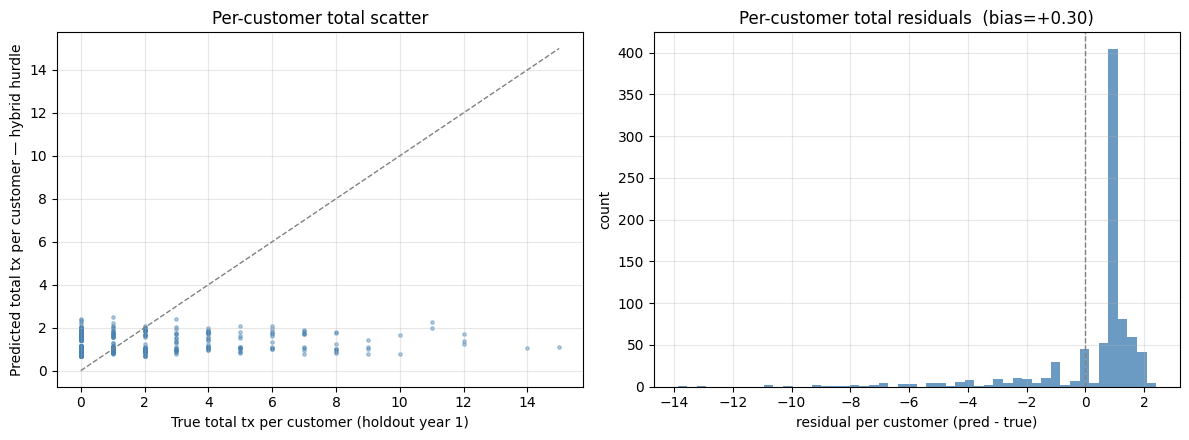

In [13]:
# === Comparison table — same 5 metrics as Data_integration.ipynb ===
cols = ["bias_%", "RMSE_agg", "MAPE_agg", "MAPE_paper", "RMSE_indiv"]
df = pd.DataFrame(results).T[cols].round(4)
df.columns = ["bias %", "RMSE (agg)", "MAPE (agg) %", "MAPE (paper) %", "RMSE (indiv)"]
print("Test-horizon metrics  (per-week aggregate across customers; same protocol as the LSTM / xLSTM / TimesMamba / Pareto baselines)")
print(df.to_string())

# Predicted vs true per-customer-total scatter for the hybrid model
y_pred_hyb_total = y_pred_hyb.sum(axis=-1)
y_true_total     = y_amt_test.sum(axis=-1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(y_true_total, y_pred_hyb_total, s=6, alpha=0.4, color="steelblue")
lim = max(y_true_total.max(), y_pred_hyb_total.max())
ax[0].plot([0, lim], [0, lim], color="grey", linestyle="--", linewidth=1)
ax[0].set_xlabel("True total tx per customer (holdout year 1)")
ax[0].set_ylabel("Predicted total tx per customer — hybrid hurdle")
ax[0].set_title(f"Per-customer total scatter")
ax[0].grid(alpha=0.3)

resid = y_pred_hyb_total - y_true_total
ax[1].hist(resid, bins=50, color="steelblue", alpha=0.8)
ax[1].axvline(0, color="grey", linestyle="--", linewidth=1)
ax[1].set_xlabel("residual per customer (pred - true)")
ax[1].set_ylabel("count")
ax[1].set_title(f"Per-customer total residuals  (bias={resid.mean():+.2f})")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


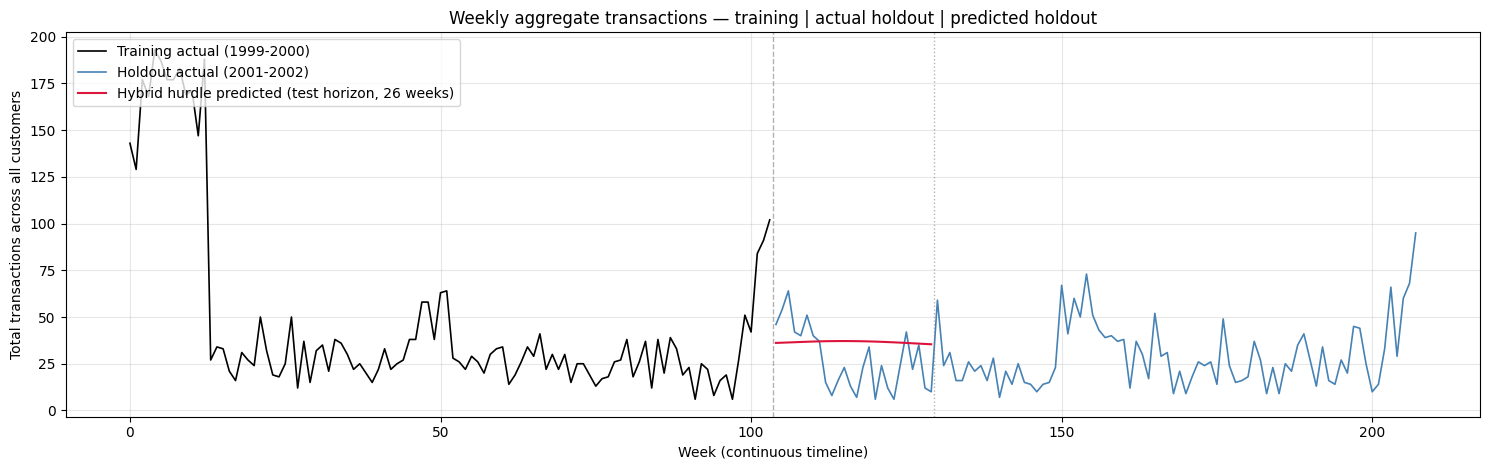

Test horizon : holdout weeks [0, 26)  (continuous-timeline x = 104 .. 129)
Total tx actual    (test horizon): 706
Total tx predicted (test horizon): 951
Bias               (pred - true): +245  (+34.7%)


In [14]:
# === Weekly aggregate plot — training, actual holdout, predicted holdout ===
# The hybrid hurdle produces a per-customer x per-week forecast. Sum over customers to
# get the aggregate weekly predicted total, then overlay on the training + holdout series.

# Aggregate weekly actuals across the FULL panel timeline (training + holdout).
weekly_agg = (panel.groupby(["year", "week"], as_index=False)["Transactions"].sum()
                   .sort_values(["year", "week"])
                   .reset_index(drop=True))
x_full      = np.arange(len(weekly_agg))                          # 0 .. T_CAL + T_HOLD - 1
y_full_act  = weekly_agg["Transactions"].to_numpy()
is_train    = (weekly_agg["year"] < holdout_start.year).to_numpy()
is_hold     = ~is_train

# Predicted weekly totals on the test horizon (sum over customers).
# The test horizon spans holdout weeks [0, HORIZON), i.e. continuous-timeline x = T_CAL .. T_CAL+HORIZON-1.
y_pred_weekly = y_pred_hyb.sum(axis=0)                            # (HORIZON,)
x_pred = np.arange(T_CAL, T_CAL + HORIZON)

fig, ax = plt.subplots(figsize=(15, 4.8))
ax.plot(x_full[is_train], y_full_act[is_train],
        color="black",     linewidth=1.2,
        label=f"Training actual ({training_start.year}-{training_end.year})")
ax.plot(x_full[is_hold],  y_full_act[is_hold],
        color="steelblue", linewidth=1.2,
        label=f"Holdout actual ({holdout_start.year}-{holdout_end.year})")
ax.plot(x_pred, y_pred_weekly,
        color="crimson",   linewidth=1.5, linestyle="-",
        label=f"Hybrid hurdle predicted (test horizon, {HORIZON} weeks)")

ax.axvline(T_CAL - 0.5,            color="grey", linestyle="--", linewidth=1, alpha=0.6)
ax.axvline(T_CAL + HORIZON - 0.5,  color="grey", linestyle=":",  linewidth=1, alpha=0.6)
ax.set_xlabel("Week (continuous timeline)")
ax.set_ylabel("Total transactions across all customers")
ax.set_title("Weekly aggregate transactions — training | actual holdout | predicted holdout")
ax.legend(loc="upper left"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Sanity: aggregate totals on the test horizon
actual_test_total = y_amt_test.sum()
pred_test_total   = y_pred_hyb.sum()
print(f"Test horizon : holdout weeks [0, {HORIZON})  (continuous-timeline x = {T_CAL} .. {T_CAL+HORIZON-1})")
print(f"Total tx actual    (test horizon): {actual_test_total:,.0f}")
print(f"Total tx predicted (test horizon): {pred_test_total:,.0f}")
print(f"Bias               (pred - true): {pred_test_total - actual_test_total:+,.0f}  "
      f"({100*(pred_test_total - actual_test_total)/max(actual_test_total,1):+.1f}%)")


y

### Why a hurdle model can beat a single-output regressor

Customer transaction data is **extremely zero-inflated**: many customers in any given year have
zero or one transaction, while a small minority concentrate most of the volume.

A **single-output regressor** trained with MSE on raw counts must compromise between the
zero-mass and the positive tail. It tends to:

- **Over-predict zeros** (positive bias on the inactive majority).
- **Under-predict high-volume customers** (negative bias on the tail).
- Be dominated by squared error on the long tail, hurting MAPE on small-value targets.

A **hurdle model** decomposes the problem:

- The **purchase head** learns the binary activation pattern with calibrated probabilities.
- The **conditional amount head** only sees positive examples (`y > 0`), so it learns the
  intensity distribution *given* that the customer is active.
- The product `p * E[amount | active]` recovers the unconditional expectation, but with
  separate parameters per regime.

In practice this often yields:

- **Lower bias** (because zero/non-zero are decoupled).
- **Lower MAPE on small targets** (the purchase head can output a near-zero probability for
  the inactive cohort).
- **Better RMSE** when the zero-mass dominates the sample size, as it does here.

The RFM/static branch provides time-invariant customer context (gender, income, lifetime
RFM aggregates) which the sequence branch cannot easily recover from short observation
windows; combining the two is what makes this a *hybrid* hurdle model.
